# Correlation & Feature Engineering
In this notebook, we will transform our data into a format suitable for machine learning and create new features that might help our model's performance.

Key tasks:
1. **Encoding Categorical Variables:** Converting text to numbers.
2. **Correlation Matrix:** Identifying which variables are most linked to Churn.
3. **Feature Engineering:** Creating `Tenure Cohorts` to see if customer age groups behave differently.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load and clean
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)

print("Data loaded and base cleaning done.")

Data loaded and base cleaning done.


## 1. Feature Engineering: Tenure Cohorts
Numeric tenure is great, but sometimes grouping customers into buckets (e.g., 0-12 months) reveals clearer patterns.

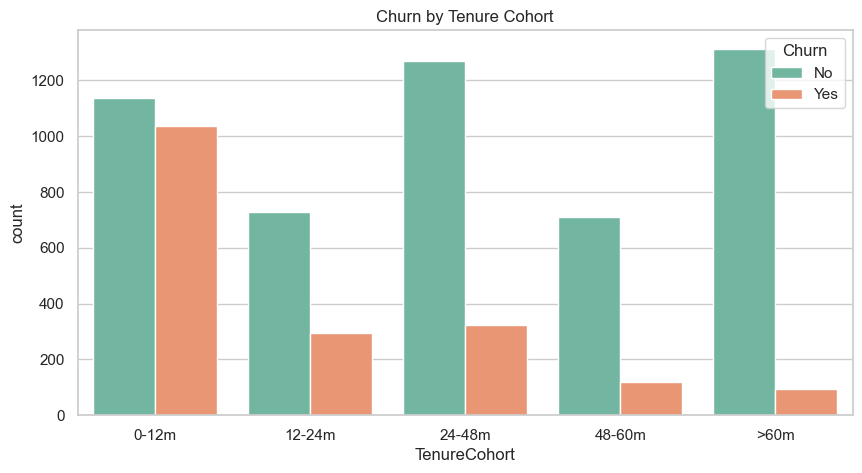

In [3]:
def map_tenure(tenure):
    if tenure <= 12:
        return '0-12m'
    elif tenure <= 24:
        return '12-24m'
    elif tenure <= 48:
        return '24-48m'
    elif tenure <= 60:
        return '48-60m'
    else:
        return '>60m'

df['TenureCohort'] = df['tenure'].apply(map_tenure)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='TenureCohort', hue='Churn', palette='Set2', order=['0-12m', '12-24m', '24-48m', '48-60m', '>60m'])
plt.title('Churn by Tenure Cohort')
plt.show()

## 2. Encoding for Correlation Analysis
To calculate correlation, we need numbers. We'll use Label Encoding for binary features and One-Hot Encoding for multi-category features.

In [4]:
# Copy for correlation works
df_encoded = df.copy()

# Binary encoding for Churn
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for all categorical variables
df_encoded = pd.get_dummies(df_encoded)

print("Shape after One-Hot Encoding:", df_encoded.shape)
df_encoded.head()

Shape after One-Hot Encoding: (7032, 51)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureCohort_0-12m,TenureCohort_12-24m,TenureCohort_24-48m,TenureCohort_48-60m,TenureCohort_>60m
0,0,1,29.85,29.85,0,True,False,False,True,True,...,True,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,False,False,True,False,False,True,False,False
2,0,2,53.85,108.15,1,False,True,True,False,True,...,True,False,False,False,True,True,False,False,False,False
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,True,False,False,True,False,True,False,False,False,False


## 3. Correlation Heatmap
Let's see which features have the strongest positive or negative correlation with `Churn`.

/var/folders/2q/59drq3tx29zgg92gy1d4870c0000gn/T/ipykernel_25258/344105571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr.values, y=churn_corr.index, palette='viridis')


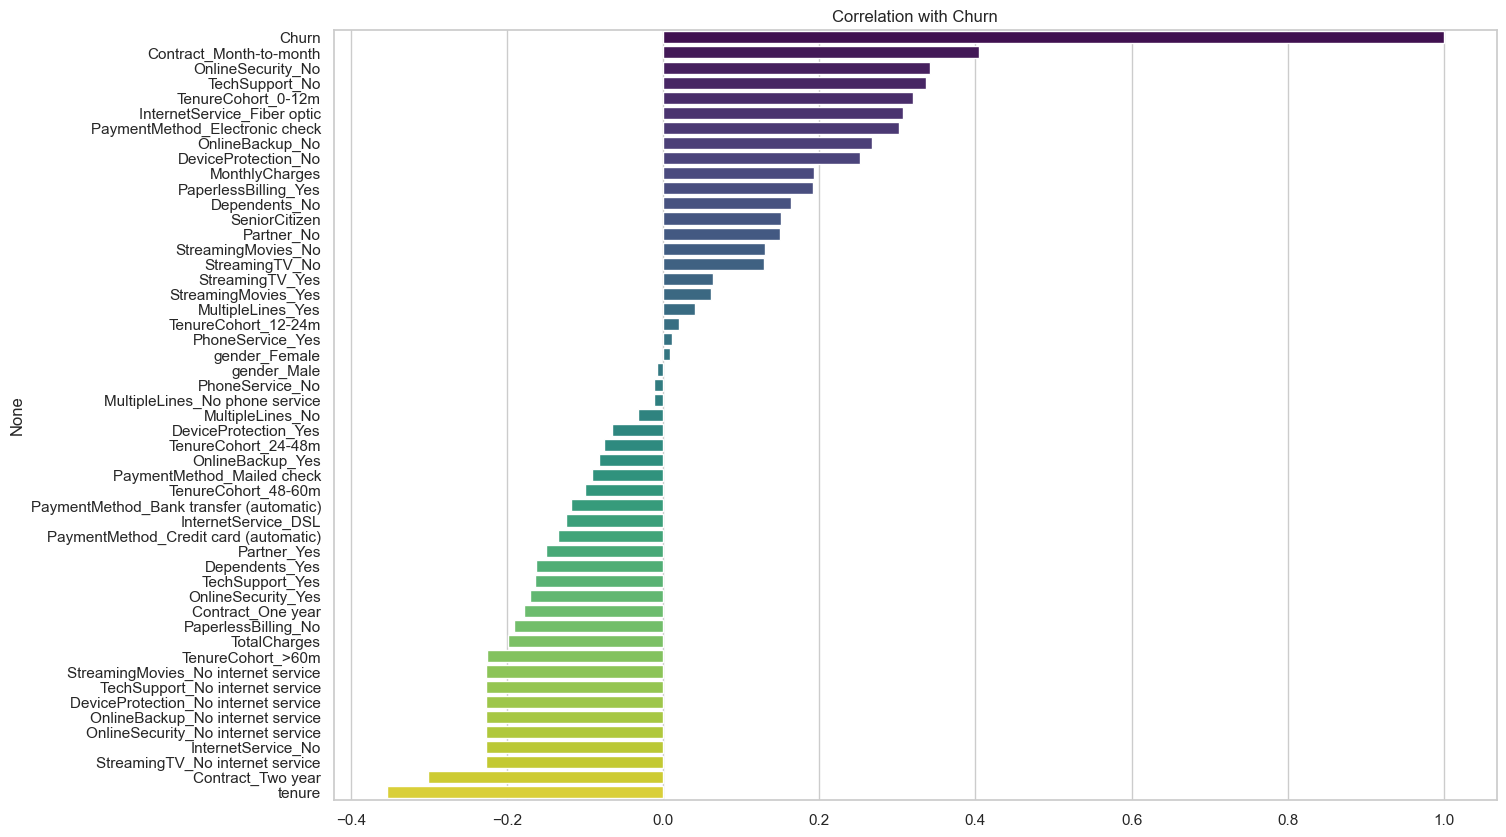

In [5]:
plt.figure(figsize=(15, 10))
churn_corr = df_encoded.corr()['Churn'].sort_values(ascending=False)
sns.barplot(x=churn_corr.values, y=churn_corr.index, palette='viridis')
plt.title('Correlation with Churn')
plt.show()

## 4. Multicollinearity Check: VIF
A VIF score above 5-10 indicates high multicollinearity. Let's check our primary suspects: `tenure`, `MonthlyCharges`, and `TotalCharges`.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# We check VIF on the numeric columns we're concerned about
vif_data = df_encoded[['tenure', 'MonthlyCharges', 'TotalCharges']]

vif_series = pd.DataFrame()
vif_series['Feature'] = vif_data.columns
vif_series['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

vif_series.sort_values(by='VIF', ascending=False)

,Feature,VIF
2,TotalCharges,8.079181
0,tenure,6.332432
1,MonthlyCharges,3.361075


## 5. Additional Feature Engineering: Services & Engagement
Beyond cohorts, we can create metrics that capture how 'involved' a customer is.

/var/folders/2q/59drq3tx29zgg92gy1d4870c0000gn/T/ipykernel_25258/1968893230.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Num_Services', palette='Set3')


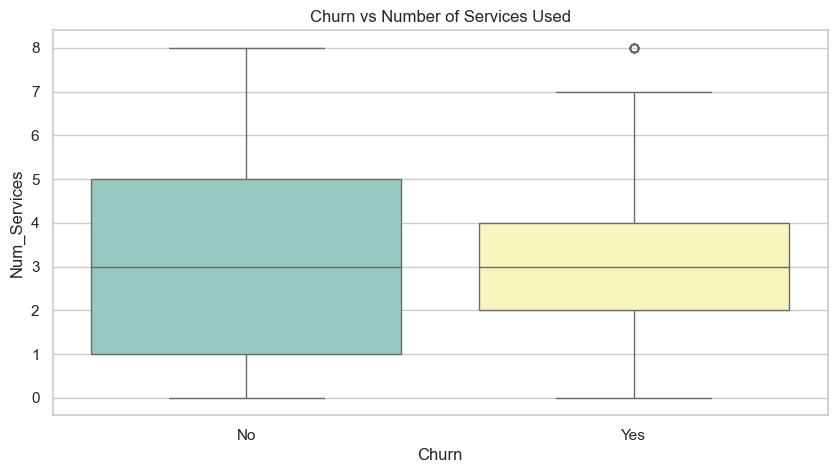

In [7]:
# 1. Total Number of Services (Bundling)
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Convert to numeric count of 'Yes'
df['Num_Services'] = (df[services] == 'Yes').sum(axis=1)

# 2. Has Internet Flag (Basic vs Digital)
df['Has_Internet'] = df['InternetService'].apply(lambda x: 1 if x != 'No' else 0)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='Num_Services', palette='Set3')
plt.title('Churn vs Number of Services Used')
plt.show()

**Observations:**
- **VIF Results:** If `TotalCharges` has a very high VIF (often > 10), we should consider dropping it for the final model, as its information is already captured by tenure and monthly charges.
- **Services:** Customers with a higher number of services (bundled) are often less likely to churn as the switching cost/effort is higher.

<Axes: xlabel='Num_Services', ylabel='count'>

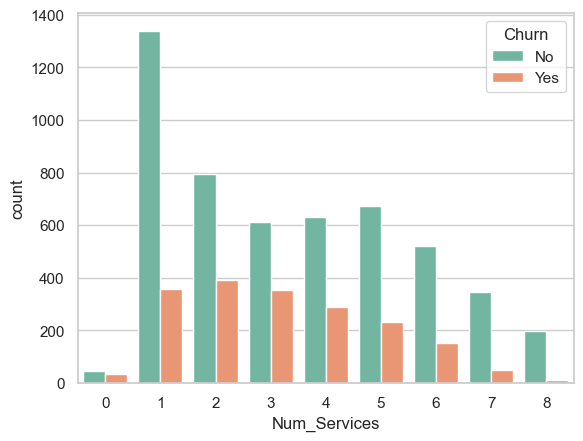

In [8]:
sns.countplot(data=df, x='Num_Services', hue='Churn', palette='Set2')
